In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

In [4]:
RESULTS_DIR = Path("../results")

# path, value_col - matches the export convention used in notebooks 01-09.
PRED_FILES = {
    "VECM": (RESULTS_DIR / "predictions_var_vecm.csv", "predicted"),
    "ARIMA": (RESULTS_DIR / "predictions_arima.csv", "predicted"),
    "FFNN": (RESULTS_DIR / "predictions_ffnn.csv", "predicted"),
    "TDNN": (RESULTS_DIR / "predictions_tdnn.csv", "predicted"),
    "LSTM": (RESULTS_DIR / "predictions_lstm.csv", "predicted"),
    "Hybrid_Residual": (RESULTS_DIR / "predictions_hybrid_residual.csv", "predicted"),
    "Hybrid_Neural": (RESULTS_DIR / "predictions_hybrid_neural.csv", "predicted"),
    "Ensemble_Simple": (RESULTS_DIR / "predictions_hybrid_ensemble.csv", "simple"),
    "Ensemble_Weighted": (RESULTS_DIR / "predictions_hybrid_ensemble.csv", "weighted"),
    "Ensemble_Stacked": (RESULTS_DIR / "predictions_hybrid_ensemble.csv", "stacked"),
}
ALPHA = 0.05
MIN_N = {"ljung_box": 8, "jarque_bera": 8, "arch_lm": 15, "adf": 8}

In [13]:
# winning model per window/target, as selected in notebook 09.
best_models = pd.read_csv(RESULTS_DIR / "best_model_by_window.csv")
best_models

,window,target,model,RMSE
0,W1,CPI,VECM,4.605201
1,W1,EXR,Hybrid_Neural,1.756537
2,W2,CPI,Ensemble_Weighted,1.868965
3,W2,EXR,VECM,5.841530
4,W3,CPI,VECM,6.516029
5,W3,EXR,ARIMA,0.643180
6,W4,CPI,Ensemble_Weighted,1.276187
7,W4,EXR,Hybrid_Residual,1.996118
8,W5,CPI,Ensemble_Stacked,8.252797
9,W5,EXR,Ensemble_Stacked,7.619369


In [14]:
def load_predictions(pred_files: dict) -> pd.DataFrame:
    cache, frames = {}, []
    for model, (path, value_col) in pred_files.items():
        if not path.exists():
            print(f"[skip] {path} not found - excluding {model}")
            continue
        if path not in cache:
            cache[path] = pd.read_csv(path, parse_dates=["date"])
        df = cache[path][["window", "target", "date", "actual", value_col]].copy()
        df = df.rename(columns={value_col: "predicted"})
        df["model"] = model
        df["residual"] = df["actual"] - df["predicted"]
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


# only load prediction files for models that actually won at least one window/target.
required = {m: PRED_FILES[m] for m in best_models["model"].unique()}
predictions = load_predictions(required)

# keep only the rows belonging to the winning (window, target, model) triples.
predictions = predictions.merge(
    best_models[["window", "target", "model"]], on=["window", "target", "model"], how="inner"
)
predictions.head()

,window,target,date,actual,predicted,model,residual
0,W1,CPI,2007-09-01,75.868308,75.359114,VECM,0.509195
1,W1,CPI,2007-10-01,78.189414,76.245431,VECM,1.943983
2,W1,CPI,2007-11-01,80.282961,77.973298,VECM,2.309663
3,W1,CPI,2007-12-01,81.056663,78.609490,VECM,2.447174
4,W1,CPI,2008-01-01,83.630813,80.908554,VECM,2.722259


In [15]:
def run_diagnostics(resid: np.ndarray) -> dict:
    n = len(resid)
    result = {"n": n, "mean_residual": np.mean(resid)}

    result["bias_p"] = stats.ttest_1samp(resid, 0.0).pvalue if n >= 3 else np.nan

    result["ljung_box_p"] = np.nan
    if n >= MIN_N["ljung_box"]:
        lags = max(1, min(10, n // 2))
        result["ljung_box_p"] = acorr_ljungbox(resid, lags=[lags], return_df=True)["lb_pvalue"].iloc[0]

    result["jarque_bera_p"] = np.nan
    if n >= MIN_N["jarque_bera"]:
        _, result["jarque_bera_p"], _, _ = jarque_bera(resid)

    result["arch_lm_p"] = np.nan
    if n >= MIN_N["arch_lm"]:
        try:
            _, result["arch_lm_p"], _, _ = het_arch(resid)
        except ValueError:
            pass

    result["adf_p"] = np.nan
    if n >= MIN_N["adf"]:
        try:
            result["adf_p"] = adfuller(resid, autolag="AIC")[1]
        except ValueError:
            pass

    return result

In [16]:
rows = []
for (model, window, target), group in predictions.groupby(["model", "window", "target"]):
    rows.append({"model": model, "window": window, "target": target,
                 **run_diagnostics(group["residual"].to_numpy())})

diagnostics = pd.DataFrame(rows)
diagnostics["unbiased"] = diagnostics["bias_p"] > ALPHA
diagnostics["no_autocorrelation"] = diagnostics["ljung_box_p"] > ALPHA
diagnostics["normal_residuals"] = diagnostics["jarque_bera_p"] > ALPHA
diagnostics["homoscedastic"] = diagnostics["arch_lm_p"] > ALPHA
diagnostics["residuals_stationary"] = diagnostics["adf_p"] < ALPHA
diagnostics

,model,window,target,n,mean_residual,bias_p,ljung_box_p,jarque_bera_p,arch_lm_p,adf_p,unbiased,no_autocorrelation,normal_residuals,homoscedastic,residuals_stationary
0,ARIMA,W3,EXR,9,0.156714,4.975361e-01,6.897034e-01,0.658340,NaN,0.367458,True,True,True,False,False
1,Ensemble_Stacked,W5,CPI,27,0.101514,9.504648e-01,3.282975e-11,0.081289,0.136233,0.013189,True,False,True,True,True
2,Ensemble_Stacked,W5,EXR,27,0.031635,9.832711e-01,1.653808e-06,0.733440,0.011365,0.547297,True,False,True,False,False
3,Ensemble_Weighted,W2,CPI,9,0.571167,3.905016e-01,1.074636e-02,0.725037,NaN,0.000349,True,False,True,False,True
4,Ensemble_Weighted,W4,CPI,4,1.140395,4.099369e-02,NaN,NaN,NaN,NaN,False,False,False,False,False
5,Hybrid_Neural,W1,EXR,13,0.377205,4.609684e-01,3.263044e-04,0.531613,NaN,0.500531,True,False,True,False,False
6,Hybrid_Residual,W4,EXR,6,-1.327315,1.031513e-01,NaN,NaN,NaN,NaN,True,False,False,False,False
7,VECM,W1,CPI,9,3.972368,1.317244e-03,8.652792e-02,0.627872,NaN,0.838762,False,True,True,False,False
8,VECM,W2,EXR,15,5.375156,4.480101e-07,9.376131e-02,0.029562,0.075985,0.055051,False,True,False,True,False
9,VECM,W3,CPI,9,3.120288,1.614472e-01,1.771723e-02,0.602736,NaN,0.030510,True,False,True,False,True


In [17]:
diagnostics.to_csv(RESULTS_DIR / "diagnostics_summary_best_models.csv", index=False)

FLAGS = ["unbiased", "no_autocorrelation", "normal_residuals", "homoscedastic", "residuals_stationary"]
diagnostics[FLAGS].mean().round(2)

unbiased                0.7
no_autocorrelation      0.3
normal_residuals        0.7
homoscedastic           0.2
residuals_stationary    0.3
dtype: float64

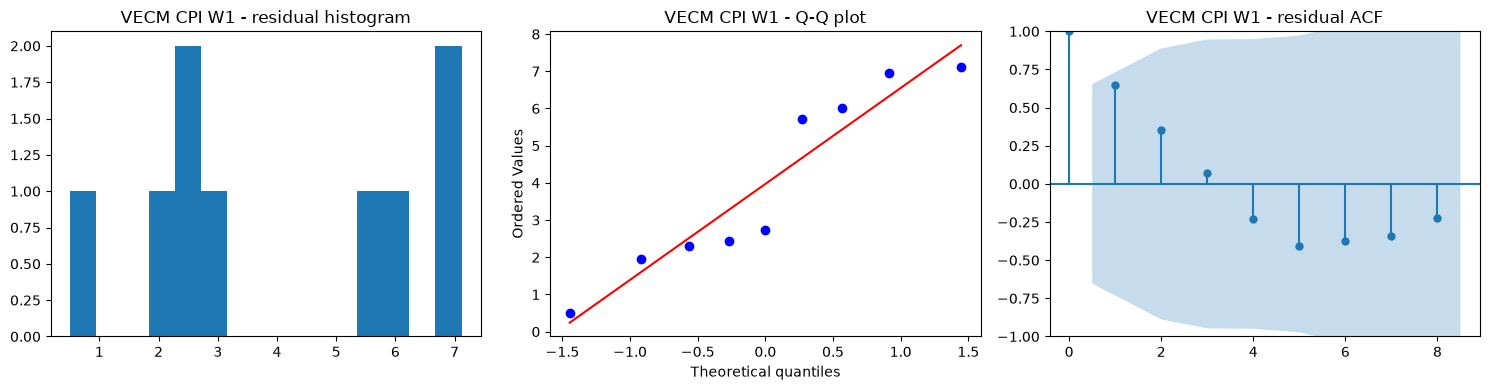

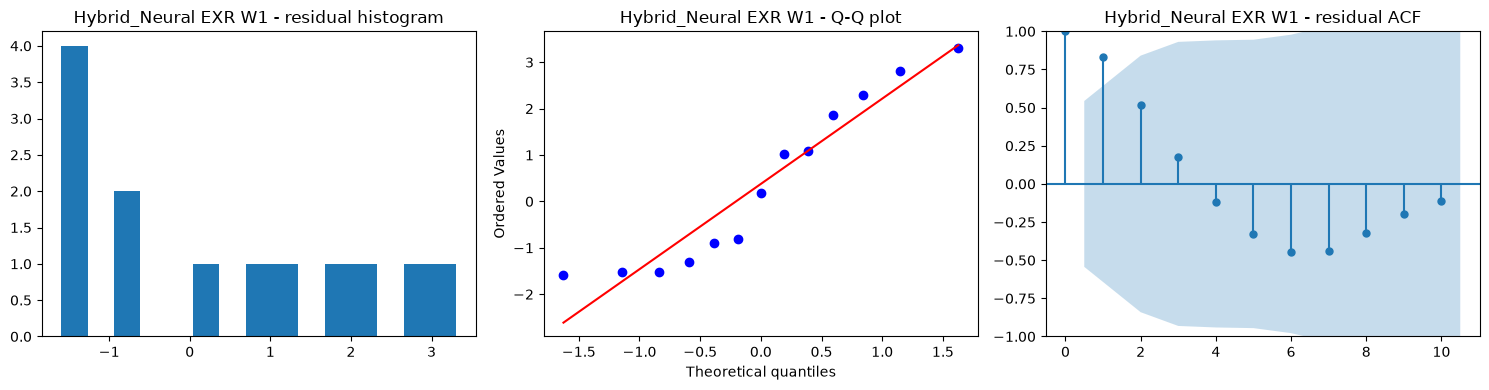

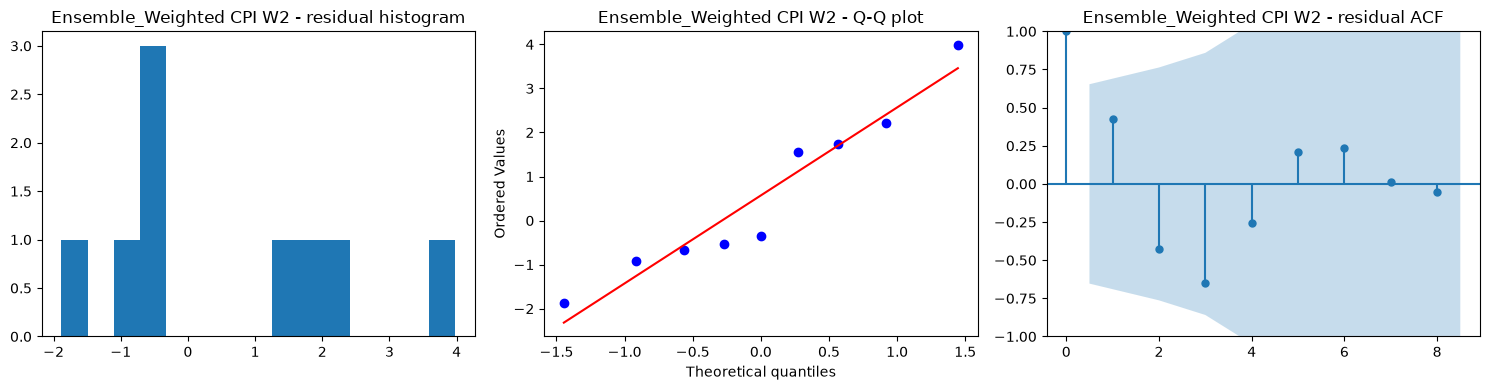

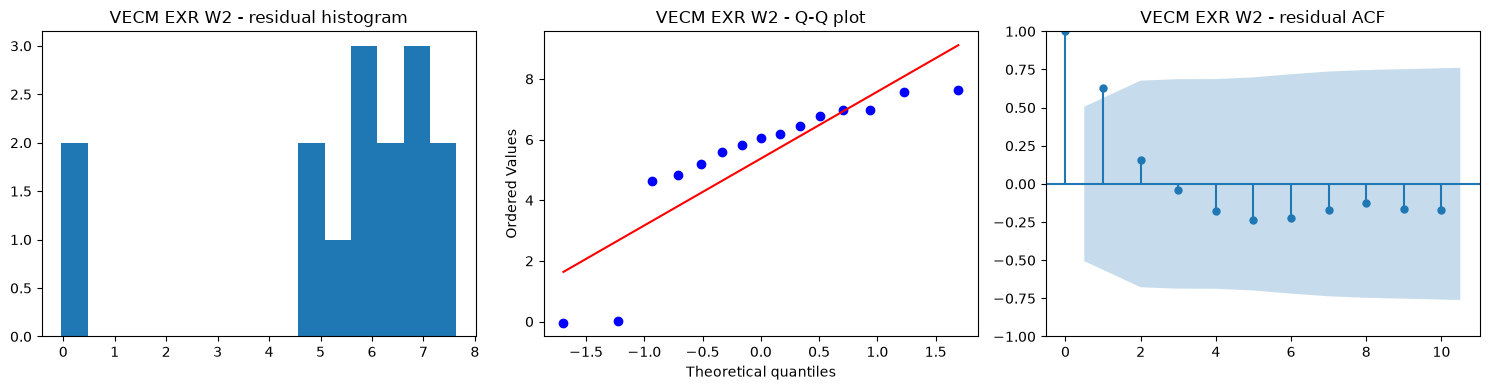

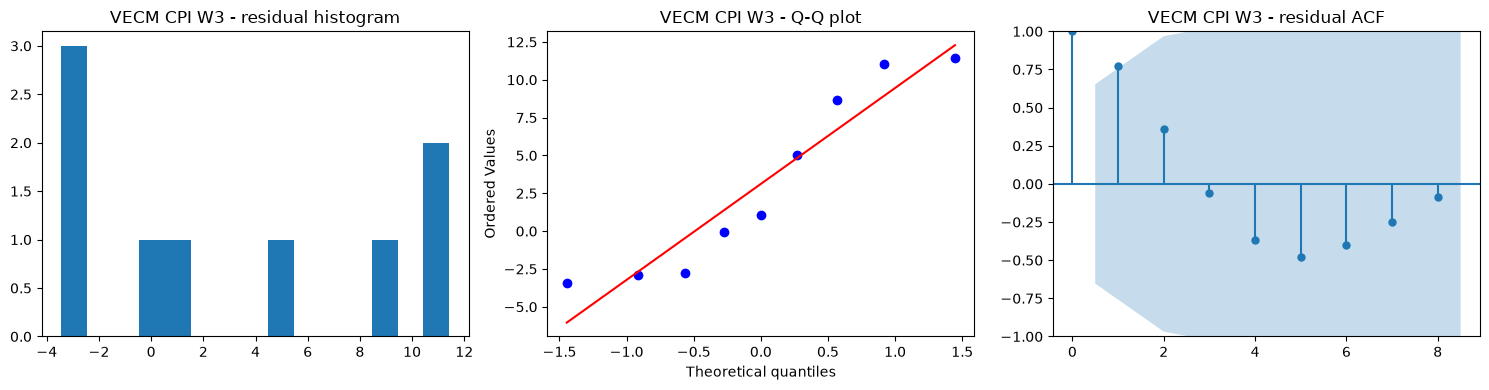

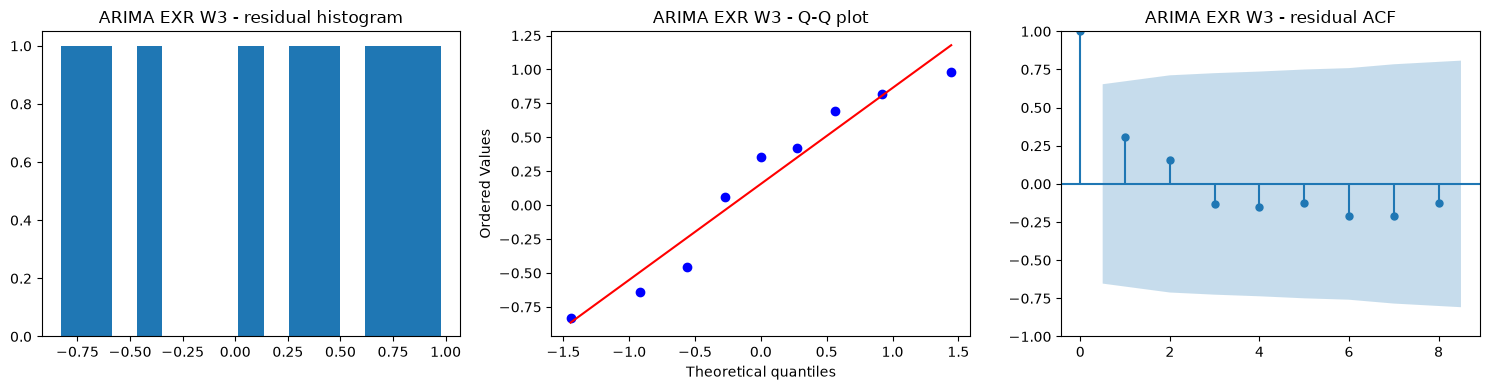

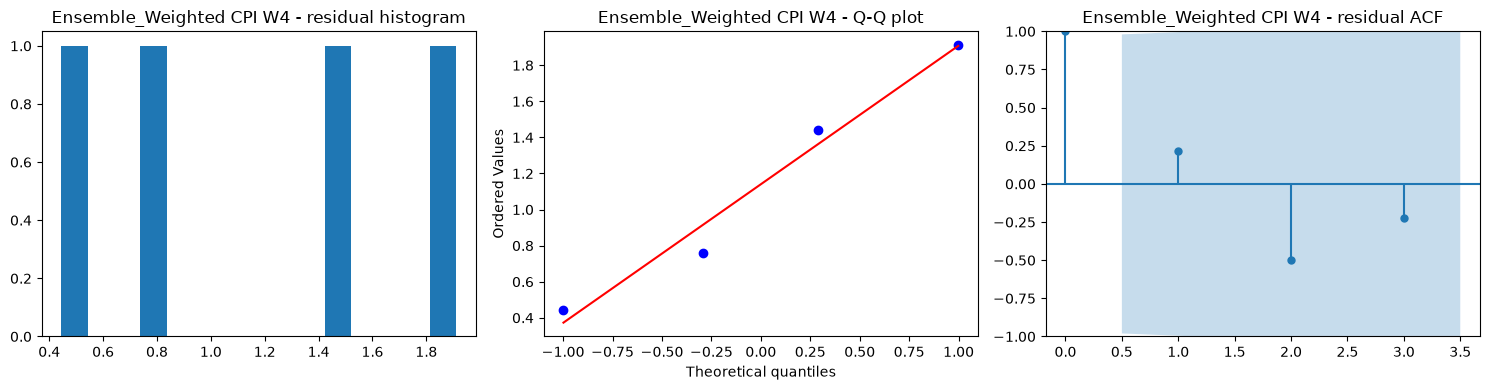

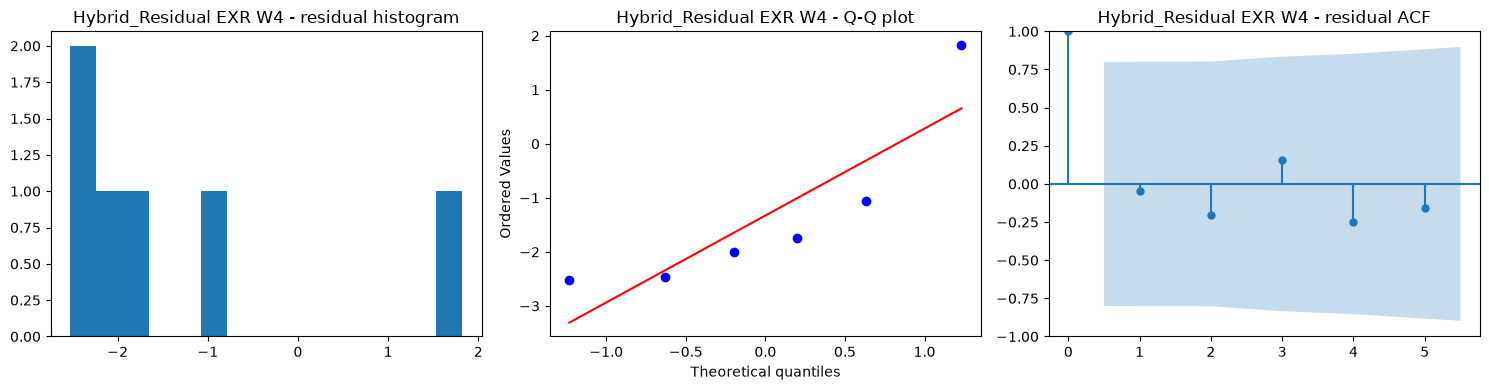

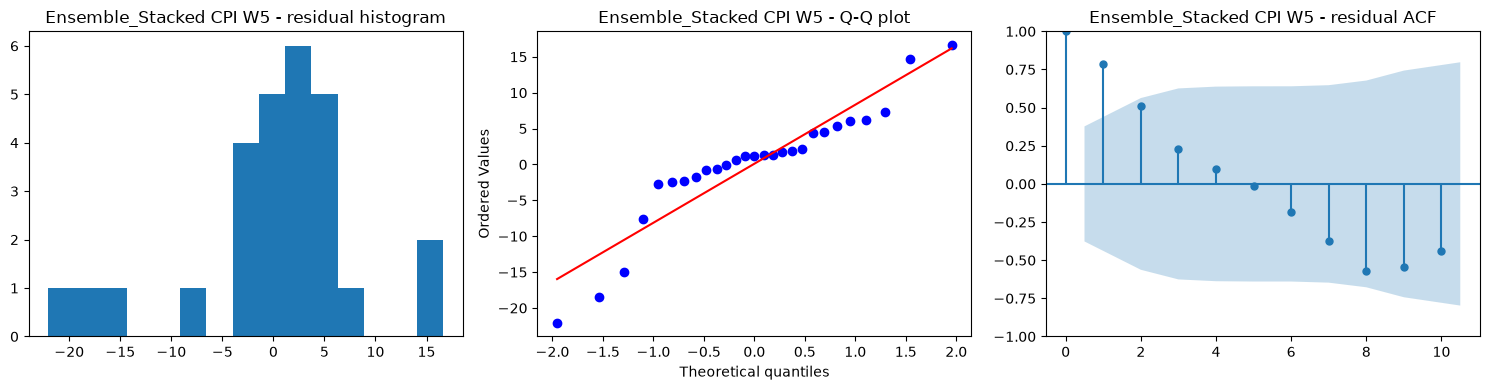

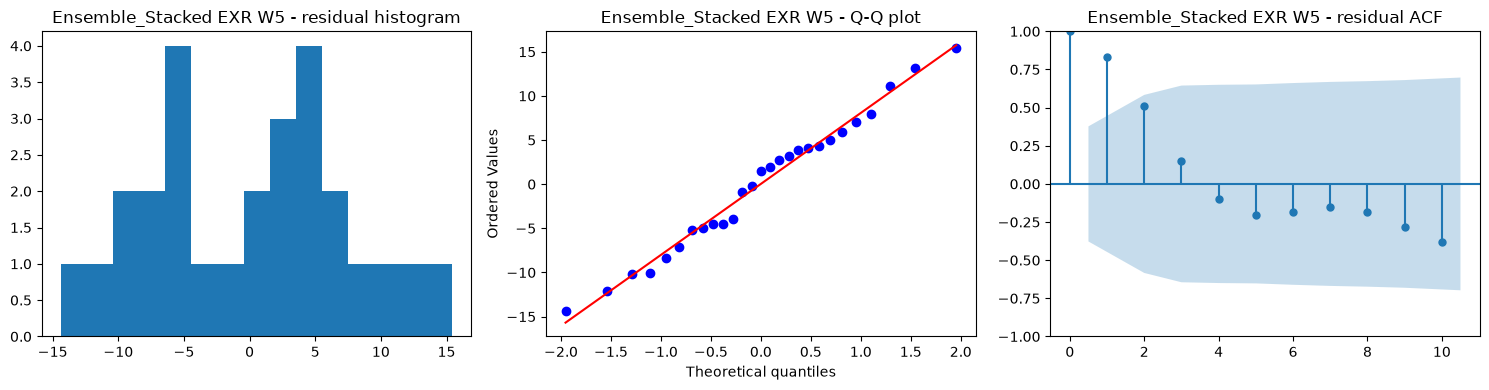

In [18]:
def plot_residual_diagnostics(model: str, window: str, target: str):
    resid = predictions.loc[
        (predictions["model"] == model) & (predictions["window"] == window) & (predictions["target"] == target),
        "residual",
    ].to_numpy()
    if len(resid) < 3:
        print(f"[skip plot] {model} {target} {window} - too few points (n={len(resid)})")
        return

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(resid, bins=15)
    axes[0].set_title(f"{model} {target} {window} - residual histogram")

    stats.probplot(resid, plot=axes[1])
    axes[1].set_title(f"{model} {target} {window} - Q-Q plot")

    plot_acf(resid, ax=axes[2], lags=min(10, len(resid) - 1))
    axes[2].set_title(f"{model} {target} {window} - residual ACF")

    fig.tight_layout()
    fig.savefig(RESULTS_DIR / f"diagnostics_{model}_{window}_{target}.png", dpi=120)
    plt.show()


for _, row in best_models.iterrows():
    plot_residual_diagnostics(row["model"], row["window"], row["target"])